# RL Group Project: Configuration B
## Clinical Treatment Optimisation: Sepsis ICU Management — Continuous Observations

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This notebook covers **Configuration B**, where the agent operates in the full continuous-observation ICU-Sepsis environment with three clinical reality wrappers injecting realistic failure modes.

---
### Group Members

Name of the Group: Group AB

```
Student 1: Andreea Roica
Student 2: Marisa Esteves
Student 3: Miguel Caramelo
Student 4: Oliver Kain
```

## 0. Setup & Imports

In [23]:
# Install dependencies (run once if needed)
# !pip install icu-sepsis numpy pandas matplotlib seaborn torch gymnasium optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
import torch
import optuna

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import importlib
import rl_configB_functions
importlib.reload(rl_configB_functions)

from rl_configB_functions import (
    # constants
    SEED, N_OBS, N_ACTIONS, GAMMA,
    # evaluation
    EvalMetricsB, evaluate_policy_b,
    # networks
    QNetwork, ActorCritic, ReplayBuffer,
    # agents
    DQNAgent, PPOAgent,
    # training
    train_dqn, train_ppo,
    # tuning
    run_optuna,
    # plotting
    moving_average, plot_return_curves, plot_survival_curves,
    dqn_convergence_episode,
)

from envs.wrappers import make_clinical_env

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots',       exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
PLOTS_DIR = 'plots'

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f'Config B | Obs dim: {N_OBS} | Actions: {N_ACTIONS} | γ = {GAMMA}')
print(f'PyTorch  : {torch.__version__}')
print(f'Optuna   : {optuna.__version__}')
print('Setup complete!')

Config B | Obs dim: 47 | Actions: 25 | γ = 1.0
PyTorch  : 2.12.0
Optuna   : 4.8.0
Setup complete!


---
## 1. Explore the Clinical Environment

Before designing any algorithm we inspect the environment structure, understand the
47-dimensional observation space, and establish a random-policy baseline.

In [24]:
env = make_clinical_env()
obs, info = env.reset(seed=SEED)

print('Clinical ICU-Sepsis environment')
print(f'  Observation space : {env.observation_space}')
print(f'  Action space      : {env.action_space}')
print(f'  Obs shape         : {obs.shape}  dtype={obs.dtype}')
print(f'  Info keys         : {list(info.keys())}')
print()
print('Wrapper stack (outermost first):')
e = env
while hasattr(e, 'env'):
    print(f'  {type(e).__name__}')
    e = e.env
print(f'  {type(e).__name__}  ← base environment')
env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical ICU-Sepsis environment
  Observation space : Box(-inf, inf, (47,), float32)
  Action space      : Discrete(25)
  Obs shape         : (47,)  dtype=float32
  Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

Wrapper stack (outermost first):
  AcuteEventEnv
  EpisodicMissingObsEnv
  EpisodicNoisyObsEnv
  ContinuousICUSepsisEnv  ← base environment


In [25]:
from envs.continuous_sepsis_env import FEATURE_NAMES

feat_df = pd.DataFrame({'index': range(len(FEATURE_NAMES)), 'feature': FEATURE_NAMES})
print(f'Physiological feature vector ({len(FEATURE_NAMES)} dimensions):')
print(feat_df.to_string(index=False))

Physiological feature vector (47 dimensions):
 index        feature
     0        Albumin
     1            ALP
     2            ALT
     3            AST
     4      Bilirubin
     5            BUN
     6       Chloride
     7     Creatinine
     8   Diastolic_BP
     9     Fibrinogen
    10           FiO2
    11            GCS
    12        Glucose
    13           HCO3
    14     Hemoglobin
    15            INR
    16        Lactate
    17          MgSO4
    18        Mean_BP
    19      Potassium
    20            PTT
    21          PaCO2
    22           PaO2
    23      Platelets
    24            RBC
    25           SOFA
    26         Sodium
    27    Systolic_BP
    28    Temperature
    29       Troponin
    30   Urine_Output
    31            WBC
    32         Weight
    33             Ca
    34        Heparin
    35             HR
    36      Na_Bicarb
    37        Insulin
    38 Norepinephrine
    39       Propofol
    40    Vasopressin
    41       Dopamine
    42  

### Random baseline

We evaluate a purely random policy on 1 000 episodes to establish a lower bound.
All trained agents must beat this baseline on survival rate and mean return.

In [26]:
np.random.seed(SEED)

clinical_rand_returns = []
noisy_returns, clean_returns    = [], []
missing_returns, nomiss_returns = [], []
acute_episodes = 0

env_eval = make_clinical_env()
for ep in range(1000):
    obs, info = env_eval.reset(seed=int(np.random.randint(100_000)))
    total_r, done = 0.0, False
    ep_noisy   = info.get('noisy_episode', False)
    ep_missing = info.get('missing_features') is not None
    ep_acute   = False

    while not done:
        obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
        total_r += r
        done     = te or tr
        if info.get('acute_event', False):
            ep_acute = True

    clinical_rand_returns.append(total_r)
    (noisy_returns   if ep_noisy   else clean_returns).append(total_r)
    (missing_returns if ep_missing else nomiss_returns).append(total_r)
    if ep_acute:
        acute_episodes += 1

env_eval.close()

clinical_rand_mean = float(np.mean(clinical_rand_returns))
clinical_rand_surv = float(np.mean(np.array(clinical_rand_returns) > 0))

print('=== Random Baseline (1 000 episodes) ===')
print(f'Overall mean return   : {clinical_rand_mean:.4f}')
print(f'Overall survival rate : {clinical_rand_surv:.1%}')
print()
print('Stratified by wrapper:')
print(f'  Noisy     ({len(noisy_returns):3d} eps) return={np.mean(noisy_returns):.4f}  surv={np.mean(np.array(noisy_returns)>0):.1%}')
print(f'  Clean     ({len(clean_returns):3d} eps) return={np.mean(clean_returns):.4f}  surv={np.mean(np.array(clean_returns)>0):.1%}')
print(f'  Missing   ({len(missing_returns):3d} eps) return={np.mean(missing_returns):.4f}  surv={np.mean(np.array(missing_returns)>0):.1%}')
print(f'  Complete  ({len(nomiss_returns):3d} eps) return={np.mean(nomiss_returns):.4f}  surv={np.mean(np.array(nomiss_returns)>0):.1%}')
print(f'  Acute event episodes : {acute_episodes} ({acute_episodes/10:.1f}%)')
print()
print('All trained agents must beat this baseline.')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (1 000 episodes) ===
Overall mean return   : 0.5527
Overall survival rate : 64.8%

Stratified by wrapper:
  Noisy     (165 eps) return=0.5587  surv=64.2%
  Clean     (835 eps) return=0.5515  surv=64.9%
  Missing   (163 eps) return=0.5163  surv=60.7%
  Complete  (837 eps) return=0.5598  surv=65.6%
  Acute event episodes : 87 (8.7%)

All trained agents must beat this baseline.


---
## 2. Experimental Configuration

### Why DQN / Double DQN?

With a 47-dimensional continuous observation space a Q-table is infeasible.
DQN uses a neural network to approximate $Q(s,a)$ across the continuous state
space. Two key stabilisation mechanisms address the instabilities of training
neural networks with RL objectives:

1. **Experience Replay** — transitions are stored in a buffer and sampled
   uniformly at random, breaking the temporal correlation of consecutive
   samples. The **buffer size** controls how much old experience is retained.
2. **Target Network** — a periodically-synced copy provides stable bootstrap
   targets, avoiding the moving-target problem. The **target update frequency**
   controls the lag between the online and target networks.

**Double DQN** further decouples action *selection* (online network) from
action *evaluation* (target network), reducing Q-value overestimation.

### Why PPO?

PPO is an on-policy policy-gradient method. It has **no replay buffer and no
target network**. It collects fresh rollouts with the current policy, computes
GAE advantages, and performs several clipped-objective update epochs before
discarding the data. This makes it a strong comparison point: we can see
whether value-based off-policy methods are better suited to this environment
than on-policy policy-gradient methods.

---
### `DEBUG_MODE` switch

Set `DEBUG_MODE = False` to run the full 50 000-episode experiments.

In [27]:
# ── master switch ──────────────────────────────────────────────────────────────
DEBUG_MODE = False          # set False for the full 50 000-episode run

# ── training budgets ──────────────────────────────────────────────────────────
N_EPISODES_FINAL = 50_000
N_EPISODES_DEBUG =  3_000
N_EPISODES = N_EPISODES_DEBUG if DEBUG_MODE else N_EPISODES_FINAL

# ── Optuna tuning budgets (kept small relative to the final run) ───────────────
N_TRIALS          = 10  if DEBUG_MODE else 20
N_EPISODES_TUNE   = 1000 if DEBUG_MODE else 2000
EVAL_EPISODES_TUNE = 150 if DEBUG_MODE else 500

# ── evaluation budget ─────────────────────────────────────────────────────────
EVAL_EPISODES = 300 if DEBUG_MODE else 1_000

# ── learning-curve smoothing window ───────────────────────────────────────────
MA_WINDOW = 100 if DEBUG_MODE else 500

print(f'DEBUG_MODE       : {DEBUG_MODE}')
print(f'Training episodes: {N_EPISODES:,}')
print(f'Optuna trials    : {N_TRIALS} × {N_EPISODES_TUNE} episodes')
print(f'Eval episodes    : {EVAL_EPISODES}')
print(f'MA window        : {MA_WINDOW}')

DEBUG_MODE       : False
Training episodes: 50,000
Optuna trials    : 20 × 2000 episodes
Eval episodes    : 1000
MA window        : 500


---
## 3. Hyperparameter Search with Optuna

We use Optuna (TPE sampler) to search for good hyperparameters for each algorithm
on a small episode budget. The best parameters found are then used for the full
50 000-episode run.

For DQN and Double DQN the search space explicitly includes **buffer_size** and
**target_update_freq** — the two key knobs that control the stability of
value-based off-policy learning.

PPO has no replay buffer or target network; its search space covers rollout
length, clip epsilon, GAE lambda and the entropy coefficient.

### 3a. Optuna — DQN (vanilla)

In [28]:
best_params_dqn, study_dqn = run_optuna(
    'dqn',
    n_trials=N_TRIALS,
    n_episodes_tune=N_EPISODES_TUNE,
    eval_episodes=EVAL_EPISODES_TUNE,
    seed=SEED,
    verbose=True,
)

print(f'\nDQN best trial  : #{study_dqn.best_trial.number}')
print(f'DQN best return : {study_dqn.best_value:.4f}')
print('DQN best params :', best_params_dqn)
print(f"buffer_size        = {best_params_dqn['buffer_size']}")
print(f"target_update_freq = {best_params_dqn['target_update_freq']}")

  0%|          | 0/20 [00:00<?, ?it/s]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[W 2026-05-28 23:58:58,887] Trial 0 failed with parameters: {'net_arch': 128, 'lr': 0.0010401663679887319, 'exploration_fraction': 0.05, 'epsilon_min': 0.01, 'batch_size': 64, 'buffer_size': 10000, 'target_update_freq': 100, 'gradient_steps': 1} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/miniconda3/envs/CIFO2526/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/Users/miguelcaramelo/Desktop/Data_Science/2_semestre/Reinforcement Learning/Project/ReinforcementLearningProject/sepsis_project - Students Version/rl_configB_functions.py", line 919, in objective
    hist = train_dqn(
        n_episodes=n_episodes_tune, double=is_double,
        seed=seed, device=device, **params,
    )
  File "/Users/miguelcaramelo/Desktop/Data_Science/2_semestre/Reinforcem

KeyboardInterrupt: 

In [ ]:
# Optuna trial summary table — DQN
dqn_trials_df = pd.DataFrame([
    {**t.params, 'return': t.value, 'trial': t.number}
    for t in study_dqn.trials if t.value is not None
]).sort_values('return', ascending=False)
display(dqn_trials_df.head(10).round(5))

# Highlight buffer_size and target_update_freq — the two assignment focus knobs
print('\nbuffer_size vs. mean return:')
print(dqn_trials_df.groupby('buffer_size')['return'].mean().round(4))
print('\ntarget_update_freq vs. mean return:')
print(dqn_trials_df.groupby('target_update_freq')['return'].mean().round(4))

,net_arch,lr,exploration_fraction,epsilon_min,batch_size,buffer_size,target_update_freq,gradient_steps,return,trial
13,256,0.00190,0.20,0.10,64,10000,100,1,0.65909,13
4,256,0.00069,0.05,0.10,128,100000,250,1,0.61046,4
0,128,0.00104,0.05,0.01,64,10000,100,1,0.59228,0
3,64,0.00010,0.05,0.01,64,10000,500,4,0.58826,3
10,256,0.00250,0.10,0.10,32,100000,250,1,0.58011,10
5,64,0.00328,0.20,0.01,128,50000,500,4,0.57759,5
1,256,0.00022,0.10,0.01,64,100000,250,1,0.57591,1
11,128,0.00044,0.20,0.10,32,10000,100,1,0.57096,11
12,128,0.00129,0.05,0.01,128,100000,250,1,0.56360,12
14,256,0.00167,0.20,0.10,32,50000,100,1,0.56312,14



buffer_size vs. mean return:
buffer_size
10000     0.5750
50000     0.5614
100000    0.5633
Name: return, dtype: float64

target_update_freq vs. mean return:
target_update_freq
50     0.5373
100    0.5808
250    0.5825
500    0.5514
Name: return, dtype: float64


### 3b. Optuna — Double DQN

In [ ]:
best_params_ddqn, study_ddqn = run_optuna(
    'ddqn',
    n_trials=N_TRIALS,
    n_episodes_tune=N_EPISODES_TUNE,
    eval_episodes=EVAL_EPISODES_TUNE,
    seed=SEED,
    verbose=True,
)

print(f'\nDouble DQN best trial  : #{study_ddqn.best_trial.number}')
print(f'Double DQN best return : {study_ddqn.best_value:.4f}')
print('Double DQN best params :', best_params_ddqn)
print(f"  → buffer_size        = {best_params_ddqn['buffer_size']}")
print(f"  → target_update_freq = {best_params_ddqn['target_update_freq']}")

  0%|          | 0/15 [00:00<?, ?it/s]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsi

KeyboardInterrupt: 

In [ ]:
# Optuna trial summary table — Double DQN
ddqn_trials_df = pd.DataFrame([
    {**t.params, 'return': t.value, 'trial': t.number}
    for t in study_ddqn.trials if t.value is not None
]).sort_values('return', ascending=False)
display(ddqn_trials_df.head(10).round(5))

print('\nbuffer_size vs. mean return (Double DQN):')
print(ddqn_trials_df.groupby('buffer_size')['return'].mean().round(4))
print('\ntarget_update_freq vs. mean return (Double DQN):')
print(ddqn_trials_df.groupby('target_update_freq')['return'].mean().round(4))

,net_arch,lr,exploration_fraction,epsilon_min,batch_size,buffer_size,target_update_freq,gradient_steps,return,trial
12,256,0.00059,0.10,0.01,128,100000,250,1,0.64204,12
4,256,0.00069,0.05,0.10,128,100000,250,1,0.62672,4
1,256,0.00022,0.10,0.01,64,100000,250,1,0.61420,1
14,256,0.00134,0.10,0.05,128,100000,250,1,0.60785,14
3,64,0.00010,0.05,0.01,64,10000,500,4,0.59880,3
6,128,0.00027,0.05,0.05,128,100000,50,2,0.59621,6
9,64,0.00086,0.05,0.01,128,10000,500,2,0.59035,9
0,128,0.00104,0.05,0.01,64,10000,100,1,0.58612,0
8,256,0.00088,0.05,0.05,128,10000,500,1,0.58399,8
2,256,0.00021,0.05,0.10,64,50000,50,2,0.57981,2



buffer_size vs. mean return (Double DQN):
buffer_size
10000     0.5898
50000     0.5444
100000    0.5933
Name: return, dtype: float64

target_update_freq vs. mean return (Double DQN):
target_update_freq
50     0.5880
100    0.5821
250    0.5951
500    0.5706
Name: return, dtype: float64


### 3c. Optuna — PPO

In [ ]:
best_params_ppo, study_ppo = run_optuna(
    'ppo',
    n_trials=N_TRIALS,
    n_episodes_tune=N_EPISODES_TUNE,
    eval_episodes=EVAL_EPISODES_TUNE,
    seed=SEED,
    verbose=True,
)

print(f'\nPPO best trial  : #{study_ppo.best_trial.number}')
print(f'PPO best return : {study_ppo.best_value:.4f}')
print('PPO best params :', best_params_ppo)

  0%|          | 0/15 [00:00<?, ?it/s]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsi

In [ ]:
# Optuna tuning summary — all three algorithms
print('Optuna tuning summary')
print(f'  DQN        best return: {study_dqn.best_value:.4f}')
print(f'  Double DQN best return: {study_ddqn.best_value:.4f}')
print(f'  PPO        best return: {study_ppo.best_value:.4f}')

Optuna tuning summary
  DQN        best return: 0.6316
  Double DQN best return: 0.6420
  PPO        best return: 0.6442


---
## 4. Final Training (up to 50 000 episodes)

Each agent is trained with its Optuna-selected hyperparameters for the full
episode budget. The DQN and Double DQN histories log the current buffer
occupancy and epsilon at each episode; PPO logs its policy loss, value loss,
entropy and clip fraction per update.

The `verbose=True` flag prints a progress line every 1 000 episodes.

### 4a. Final training — DQN 

In [ ]:
hist_dqn = train_dqn(
    n_episodes=N_EPISODES,
    double=False,
    seed=SEED,
    verbose=True,
    log_every=max(1, N_EPISODES // 10),
    **best_params_dqn,
)

agent_dqn = hist_dqn['agent']
print(f"\nDQN done  | buffer_size={best_params_dqn['buffer_size']} "
      f"| target_update_freq={best_params_dqn['target_update_freq']}")

# Save checkpoint
torch.save(agent_dqn.online_net.state_dict(), 'checkpoints/dqn_configB.pt')
print('Checkpoint saved: checkpoints/dqn_configB.pt')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN] Ep   5000/50000 | Return 0.562 | Survival 65.48% | ε=0.1000 | buffer= 47246
[DQN] Ep  10000/50000 | Return 0.559 | Survival 65.32% | ε=0.1000 | buffer= 95323
[DQN] Ep  15000/50000 | Return 0.554 | Survival 64.62% | ε=0.1000 | buffer=100000
[DQN] Ep  20000/50000 | Return 0.549 | Survival 64.16% | ε=0.1000 | buffer=100000
[DQN] Ep  25000/50000 | Return 0.557 | Survival 65.00% | ε=0.1000 | buffer=100000
[DQN] Ep  30000/50000 | Return 0.559 | Survival 65.32% | ε=0.1000 | buffer=100000
[DQN] Ep  35000/50000 | Return 0.563 | Survival 65.82% | ε=0.1000 | buffer=100000
[DQN] Ep  40000/50000 | Return 0.560 | Survival 65.24% | ε=0.1000 | buffer=100000
[DQN] Ep  45000/50000 | Return 0.562 | Survival 65.44% | ε=0.1000 | buffer=100000
[DQN] Ep  50000/50000 | Return 0.558 | Survival 65.20% | ε=0.1000 | buffer=100000

DQN done  | buffer_size=100000 | target_update_freq=250
Checkpoint sa

### 4b. Final training — Double DQN

In [ ]:
hist_ddqn = train_dqn(
    n_episodes=N_EPISODES,
    double=True,
    seed=SEED,
    verbose=True,
    log_every=max(1, N_EPISODES // 10),
    **best_params_ddqn,
)

agent_ddqn = hist_ddqn['agent']
print(f"\nDouble DQN done  | buffer_size={best_params_ddqn['buffer_size']} "
      f"| target_update_freq={best_params_ddqn['target_update_freq']}")

torch.save(agent_ddqn.online_net.state_dict(), 'checkpoints/ddqn_configB.pt')
print('Checkpoint saved: checkpoints/ddqn_configB.pt')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double DQN] Ep   5000/50000 | Return 0.566 | Survival 65.90% | ε=0.0102 | buffer= 47081
[Double DQN] Ep  10000/50000 | Return 0.552 | Survival 64.18% | ε=0.0100 | buffer= 93256
[Double DQN] Ep  15000/50000 | Return 0.553 | Survival 64.48% | ε=0.0100 | buffer=100000
[Double DQN] Ep  20000/50000 | Return 0.562 | Survival 65.80% | ε=0.0100 | buffer=100000
[Double DQN] Ep  25000/50000 | Return 0.559 | Survival 65.46% | ε=0.0100 | buffer=100000
[Double DQN] Ep  30000/50000 | Return 0.555 | Survival 64.80% | ε=0.0100 | buffer=100000
[Double DQN] Ep  35000/50000 | Return 0.549 | Survival 64.28% | ε=0.0100 | buffer=100000
[Double DQN] Ep  40000/50000 | Return 0.552 | Survival 64.60% | ε=0.0100 | buffer=100000
[Double DQN] Ep  45000/50000 | Return 0.566 | Survival 66.04% | ε=0.0100 | buffer=100000
[Double DQN] Ep  50000/50000 | Return 0.564 | Survival 65.86% | ε=0.0100 | buffer=100000


### 4c. Final training — PPO

In [ ]:
hist_ppo = train_ppo(
    n_episodes=N_EPISODES,
    seed=SEED,
    verbose=True,
    log_every=max(1, N_EPISODES // 10),
    **best_params_ppo,
)

agent_ppo = hist_ppo['agent']
upd = hist_ppo['ppo_updates']
if upd['policy_loss']:
    print(f"\nPPO done | last update: p_loss={upd['policy_loss'][-1]:.4f} "
          f"v_loss={upd['value_loss'][-1]:.4f} "
          f"entropy={upd['entropy'][-1]:.3f} "
          f"clip={upd['clip_fraction'][-1]:.3f}")

torch.save(agent_ppo.net.state_dict(), 'checkpoints/ppo_configB.pt')
print('Checkpoint saved: checkpoints/ppo_configB.pt')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PPO] Ep   5000/50000 | Return 0.571 | Survival 65.60% | p_loss=-0.0201 entropy=2.821


KeyboardInterrupt: 

---
## 5. Learning Curves

Two focused plots comparing DQN, Double DQN and PPO on the same figure over
the full training run:

1. **Episode return** — did the agent learn to accumulate higher reward?
2. **Survival rate** — is the agent keeping patients alive more often?

All curves use a causal moving average of window `MA_WINDOW` (preserves
episode alignment) and include the random-policy baseline for reference.

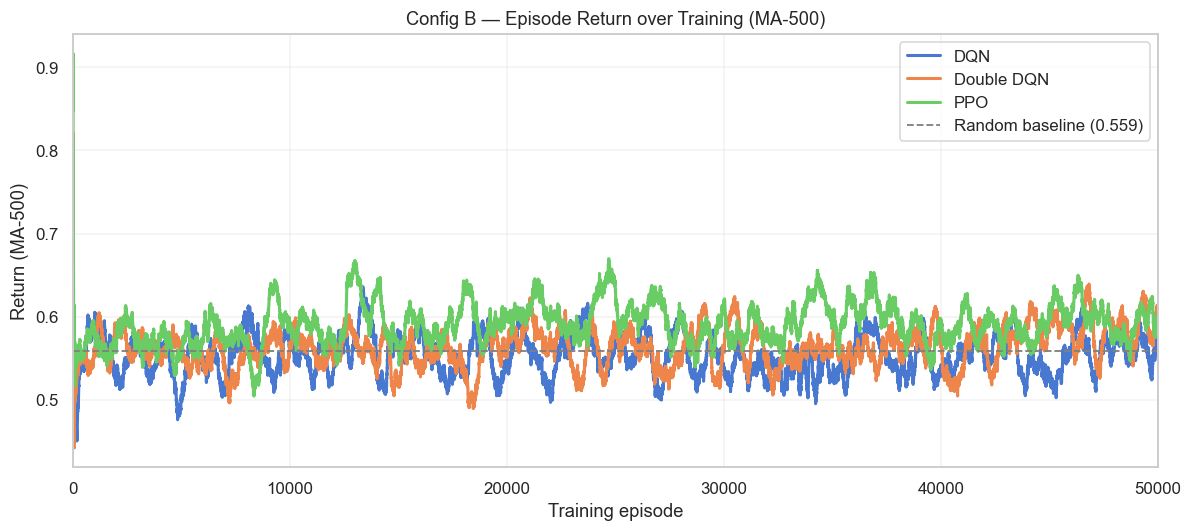

In [ ]:
histories = {
    'DQN':        hist_dqn,
    'Double DQN': hist_ddqn,
    'PPO':        hist_ppo,
}
baselines = {
    f'Random baseline ({clinical_rand_mean:.3f})': clinical_rand_mean,
}

plot_return_curves(
    histories,
    window=MA_WINDOW,
    title=f'Config B — Episode Return over Training (MA-{MA_WINDOW})',
    baselines=baselines,
    max_episodes=N_EPISODES,
    savepath=f'{PLOTS_DIR}/configB_returns.png',
)

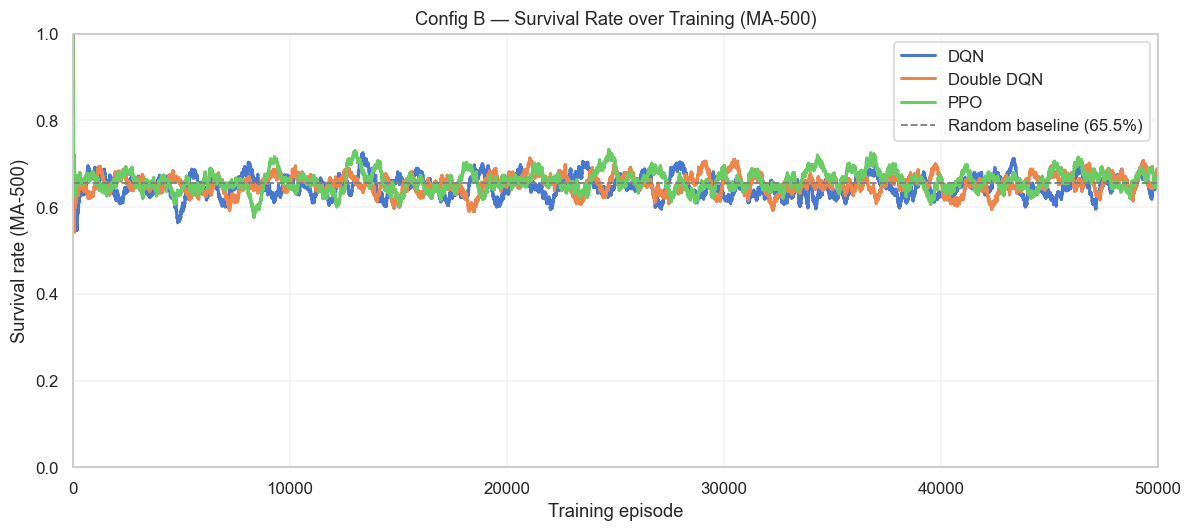

In [ ]:
baselines_surv = {
    f'Random baseline ({clinical_rand_surv:.1%})': clinical_rand_surv,
}

plot_survival_curves(
    histories,
    window=MA_WINDOW,
    title=f'Config B — Survival Rate over Training (MA-{MA_WINDOW})',
    baselines=baselines_surv,
    max_episodes=N_EPISODES,
    savepath=f'{PLOTS_DIR}/configB_survival.png',
)

### 5a. DQN-specific plots: epsilon decay and loss

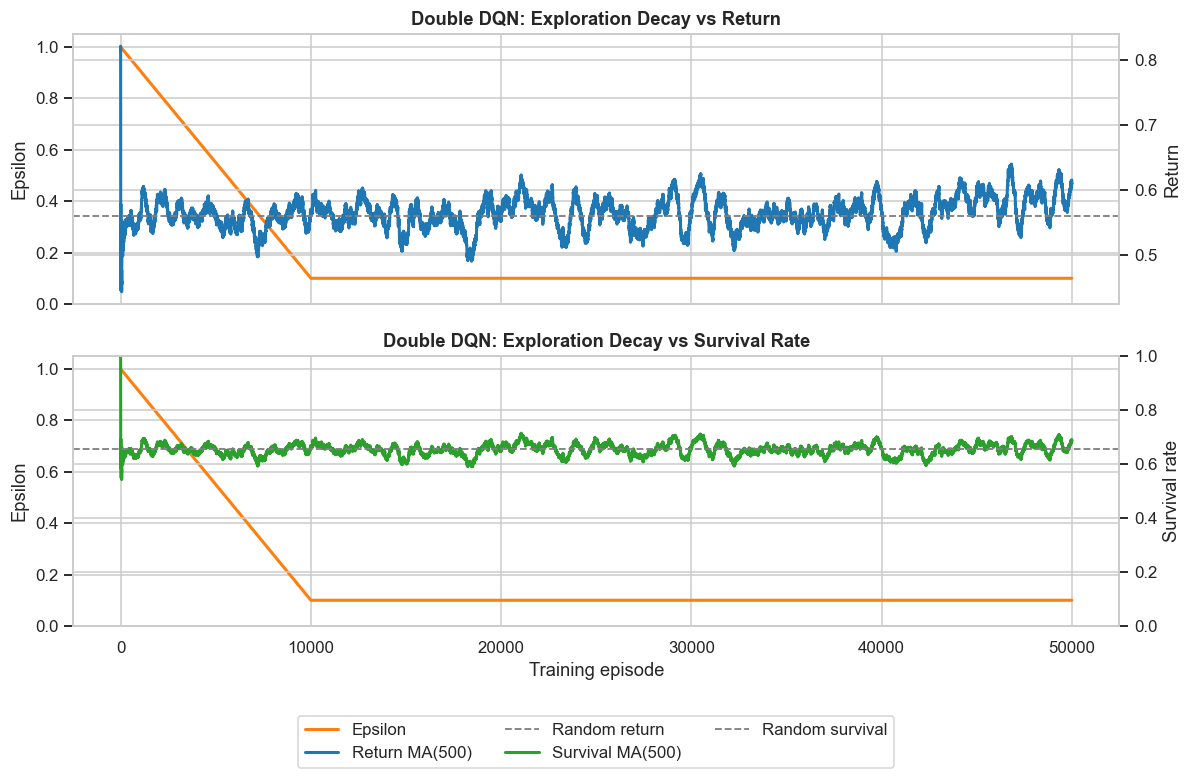

In [ ]:
# Plot style
BLUE        = '#1f77b4'
LIGHT_BLUE  = '#7fb3d5'
GREEN       = '#2ca02c'
LIGHT_GREEN = '#98df8a'
ORANGE      = '#ff7f0e'
RED         = '#d62728'

# Epsilon decay vs return / survival (for DQN)
epsilons     = np.array(hist_ddqn['epsilons'])
returns_ma   = moving_average(hist_ddqn['returns'],   MA_WINDOW)
survival_ma  = moving_average([float(s) for s in hist_ddqn['survivals']], MA_WINDOW)
episodes     = np.arange(1, len(epsilons) + 1)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1 = axes[0]
ax1.plot(episodes, epsilons, color=ORANGE, linewidth=2, label='Epsilon')
ax1.set_ylabel('Epsilon')
ax1.set_ylim(0, 1.05)
ax1b = ax1.twinx()
ax1b.plot(episodes, returns_ma, color=BLUE, linewidth=2, label=f'Return MA({MA_WINDOW})')
ax1b.axhline(clinical_rand_mean, color='gray', linestyle='--', linewidth=1.2, label='Random return')
ax1b.set_ylabel('Return')
ax1.set_title('Double DQN: Exploration Decay vs Return', fontweight='bold')

ax2 = axes[1]
ax2.plot(episodes, epsilons, color=ORANGE, linewidth=2, label='Epsilon')
ax2.set_ylabel('Epsilon')
ax2.set_xlabel('Training episode')
ax2.set_ylim(0, 1.05)
ax2b = ax2.twinx()
ax2b.plot(episodes, survival_ma, color=GREEN, linewidth=2, label=f'Survival MA({MA_WINDOW})')
ax2b.axhline(clinical_rand_surv, color='gray', linestyle='--', linewidth=1.2, label='Random survival')
ax2b.set_ylabel('Survival rate')
ax2b.set_ylim(0, 1)
ax2.set_title('Double DQN: Exploration Decay vs Survival Rate', fontweight='bold')

handles, labels = [], []
for ax in [ax1, ax1b, ax2b]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h); labels.extend(l)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(f'{PLOTS_DIR}/configB_epsilon_vs_performance.png', bbox_inches='tight')
plt.show()

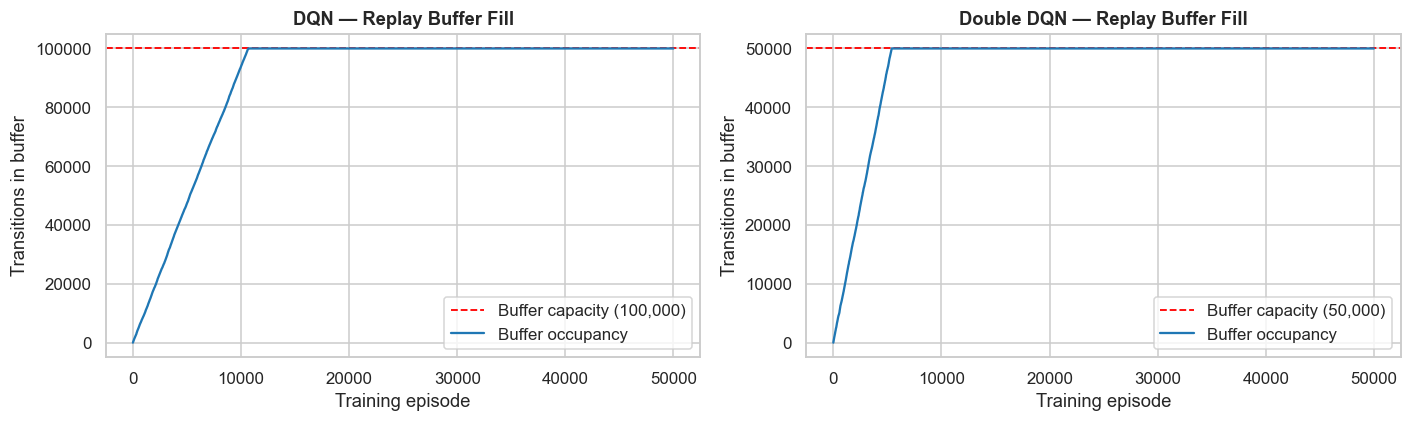

In [ ]:
# Buffer occupancy over training — shows when the buffer is full
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, label, hist, bs in [
    (axes[0], 'DQN',        hist_dqn,  best_params_dqn['buffer_size']),
    (axes[1], 'Double DQN', hist_ddqn, best_params_ddqn['buffer_size']),
]:
    # Buffer occupancy is the number of transitions currently stored
    buf_occ = []
    cap = bs
    for i, steps in enumerate(hist['lengths']):
        n = min((i + 1) * int(np.mean(hist['lengths'][:i+1])) if i > 0 else steps, cap)
        buf_occ.append(n)
    ax.axhline(bs, color='red', linestyle='--', linewidth=1.2, label=f'Buffer capacity ({bs:,})')
    ax.plot(
        np.minimum(np.cumsum(hist['lengths']), bs),
        color=BLUE, linewidth=1.5, label='Buffer occupancy'
    )
    ax.set_xlabel('Training episode')
    ax.set_ylabel('Transitions in buffer')
    ax.set_title(f'{label} — Replay Buffer Fill', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_buffer_fill.png', bbox_inches='tight')
plt.show()

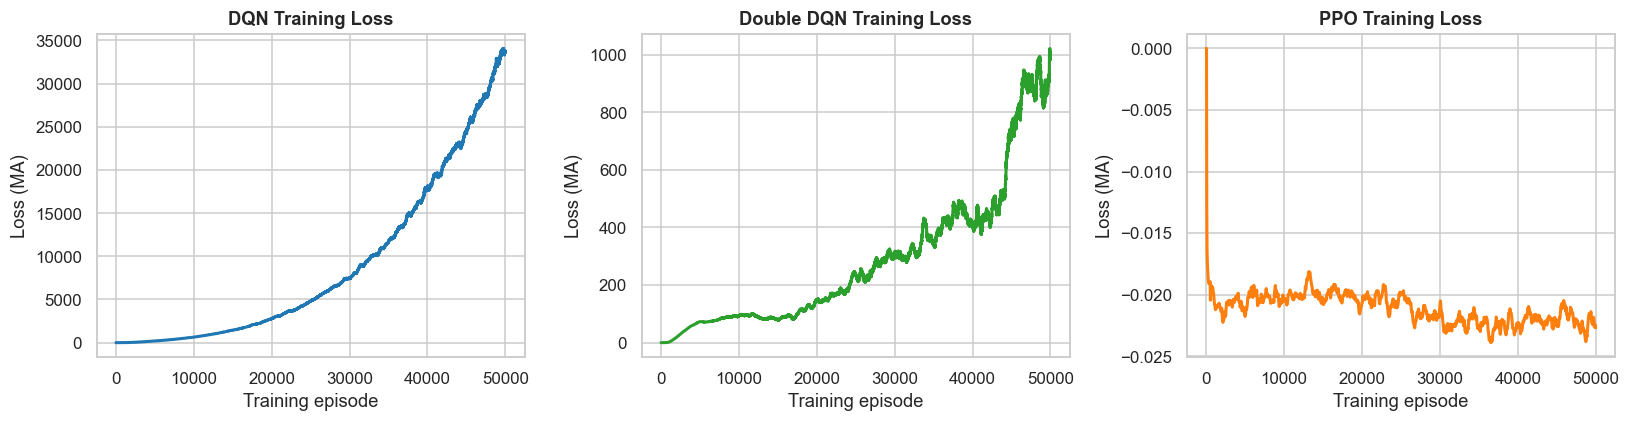

In [ ]:
# Training loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, label, hist, color in [
    (axes[0], 'DQN',        hist_dqn,  BLUE),
    (axes[1], 'Double DQN', hist_ddqn, GREEN),
    (axes[2], 'PPO',        hist_ppo,  ORANGE),
]:
    ma_loss = moving_average(hist['losses'], MA_WINDOW)
    ax.plot(np.arange(len(ma_loss)), ma_loss, color=color, linewidth=2)
    ax.set_xlabel('Training episode')
    ax.set_ylabel('Loss (MA)')
    ax.set_title(f'{label} Training Loss', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_losses.png', bbox_inches='tight')
plt.show()

---
## 6. Evaluation

All three trained agents are evaluated on the same 1 000 greedy episodes
(no exploration). We stratify results by wrapper flag to understand each
agent's robustness to the clinical failure modes.

In [ ]:
agents = {'DQN': agent_dqn, 'Double DQN': agent_ddqn, 'PPO': agent_ppo}
eval_results = {}

for name, agent in agents.items():
    m = evaluate_policy_b(agent, n_episodes=EVAL_EPISODES, seed=SEED)
    s = m.summary()
    eval_results[name] = {'metrics': m, 'summary': s}
    print(f"{name:13s} | return={s['mean_return']:.4f} | "
          f"survival={s['survival_rate']:.2%} | length={s['mean_length']:.2f}")

print()
print(f"Random baseline  | return={clinical_rand_mean:.4f} | "
      f"survival={clinical_rand_surv:.2%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DQN           | return=0.5284 | survival=64.10% | length=9.74
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Double DQN    | return=0.5402 | survival=65.40% | length=9.23
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PPO           | return=0.6153 | survival=66.90% | length=8.72

Random baseline  | return=0.5591 | survival=65.50%


In [ ]:
# Stratified evaluation: noisy, missing, acute
for name, agent in agents.items():
    m = evaluate_policy_b(agent, n_episodes=2000, seed=SEED)
    returns_arr  = np.array(m.episode_returns)
    noisy_mask   = np.array(m.noisy_flags)
    missing_mask = np.array(m.missing_flags)
    acute_mask   = np.array(m.acute_flags)

    print(f'\n=== {name} — stratified evaluation (2000 episodes) ===')
    for mask, lbl in [(noisy_mask,  'Noisy'),
                      (~noisy_mask, 'Clean'),
                      (missing_mask,'Missing obs'),
                      (~missing_mask,'Complete obs'),
                      (acute_mask,  'Acute event'),
                      (~acute_mask, 'No acute')]:
        if mask.sum() == 0:
            continue
        sel = returns_arr[mask]
        print(f'  {lbl:16s} n={mask.sum():4d}  return={np.mean(sel):.4f}  surv={np.mean(sel>0):.1%}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== DQN — stratified evaluation (2000 episodes) ===
  Noisy            n= 304  return=0.5124  surv=62.8%
  Clean            n=1696  return=0.5469  surv=65.6%
  Missing obs      n= 296  return=0.5536  surv=66.2%
  Complete obs     n=1704  return=0.5396  surv=65.0%
  Acute event      n= 161  return=-0.1101  surv=0.0%
  No acute         n=1839  return=0.5987  surv=70.9%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Double DQN — stratified evaluation (2000 episodes) ===
  Noisy            n= 271  return=0.5295  surv=64.2%
  Clean            n=1729  return=0.5368  surv=65.2%
  Missing obs      n= 333  return=0.5593  surv=68.2%
  Complete obs     n=1667  return=0.5312  surv=64.5%
  Acute event      n= 188  return=-0.1057  surv=0.0%
  No acute         n=1812  return=0.6024  surv=71.9%
make_sepsis_env | lam=0.02 → in

---
## 7. Failure Mode Sensitivity Analysis

We vary each wrapper intensity while holding the others fixed, to understand
how robust the best agent is to increasing clinical realism.

Best agent for sensitivity analysis: PPO
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bi

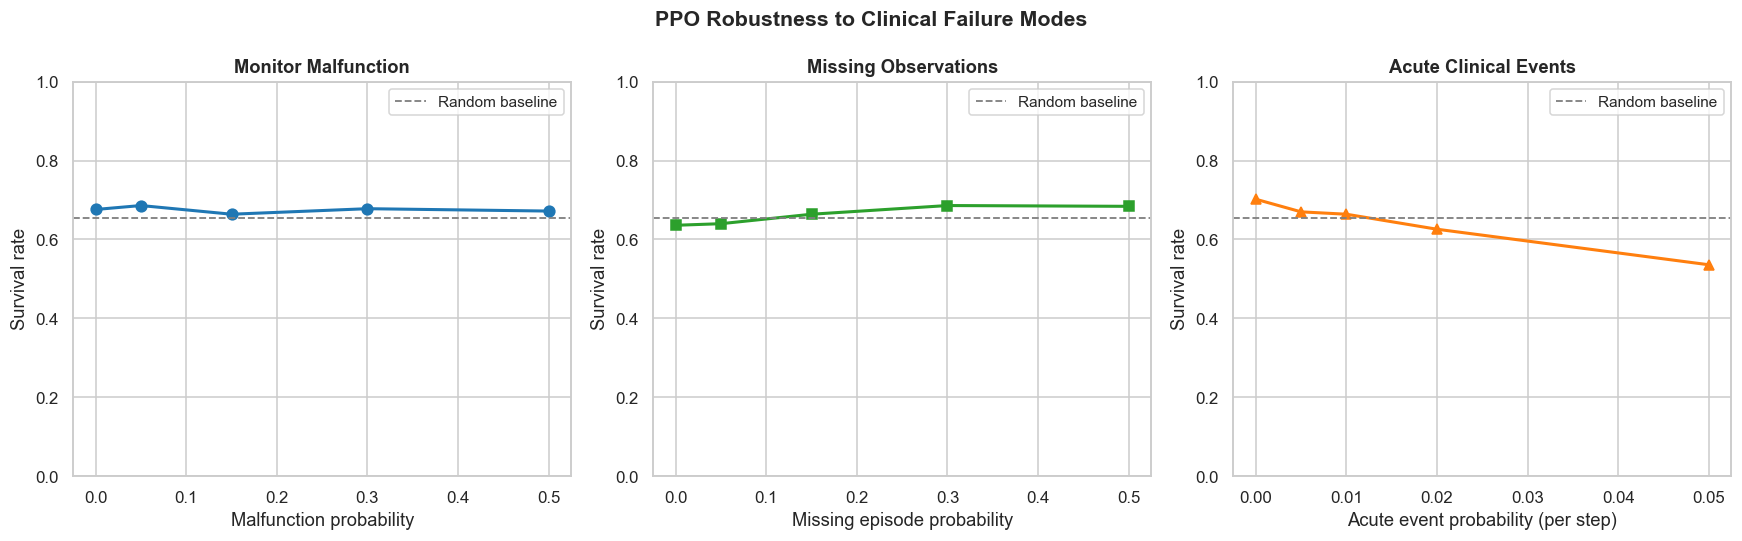

In [ ]:
# Use the best-performing agent on clean evaluation
best_agent_name = max(eval_results, key=lambda n: eval_results[n]['summary']['survival_rate'])
best_agent      = agents[best_agent_name]
print(f'Best agent for sensitivity analysis: {best_agent_name}')

noise_probs   = [0.0, 0.05, 0.15, 0.30, 0.50]
missing_probs = [0.0, 0.05, 0.15, 0.30, 0.50]
event_probs   = [0.0, 0.005, 0.01, 0.02, 0.05]

noise_results   = []
missing_results = []
event_results   = []

for prob in noise_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, malfunction_prob=prob).summary()
    noise_results.append({'malfunction_prob': prob, **m})

for prob in missing_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, missing_prob=prob).summary()
    missing_results.append({'missing_prob': prob, **m})

for prob in event_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, event_prob=prob).summary()
    event_results.append({'event_prob': prob, **m})

noise_df   = pd.DataFrame(noise_results)
missing_df = pd.DataFrame(missing_results)
event_df   = pd.DataFrame(event_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(noise_df['malfunction_prob'],  noise_df['survival_rate'],
             'o-', color=BLUE, linewidth=2, markersize=7)
axes[0].set_title('Monitor Malfunction', fontweight='bold')
axes[0].set_xlabel('Malfunction probability')
axes[0].set_ylabel('Survival rate')
axes[0].set_ylim(0, 1)

axes[1].plot(missing_df['missing_prob'], missing_df['survival_rate'],
             's-', color=GREEN, linewidth=2, markersize=7)
axes[1].set_title('Missing Observations', fontweight='bold')
axes[1].set_xlabel('Missing episode probability')
axes[1].set_ylabel('Survival rate')
axes[1].set_ylim(0, 1)

axes[2].plot(event_df['event_prob'], event_df['survival_rate'],
             '^-', color=ORANGE, linewidth=2, markersize=7)
axes[2].set_title('Acute Clinical Events', fontweight='bold')
axes[2].set_xlabel('Acute event probability (per step)')
axes[2].set_ylabel('Survival rate')
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.axhline(clinical_rand_surv, color='gray', linestyle='--',
               linewidth=1.2, label='Random baseline')
    ax.legend(fontsize=10)

fig.suptitle(f'{best_agent_name} Robustness to Clinical Failure Modes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_failure_mode_sensitivity.png', bbox_inches='tight')
plt.show()

---
## 8. Final Comparison

In [ ]:
# Summary table
rows = []
rows.append({
    'Algorithm': 'Random',
    'Mean Return': clinical_rand_mean,
    'Survival Rate': clinical_rand_surv,
    'Training Episodes': 0,
    'buffer_size': '-',
    'target_update_freq': '-',
})
for name in ['DQN', 'Double DQN', 'PPO']:
    s = eval_results[name]['summary']
    row = {
        'Algorithm': name,
        'Mean Return': round(s['mean_return'], 4),
        'Survival Rate': round(s['survival_rate'], 4),
        'Training Episodes': N_EPISODES,
    }
    if name in ('DQN', 'Double DQN'):
        p = best_params_dqn if name == 'DQN' else best_params_ddqn
        row['buffer_size']        = p['buffer_size']
        row['target_update_freq'] = p['target_update_freq']
    else:
        row['buffer_size']        = 'N/A (on-policy)'
        row['target_update_freq'] = 'N/A (on-policy)'
    rows.append(row)

comparison_df = pd.DataFrame(rows)
print('Final comparison table:')
display(comparison_df)

Final comparison table:


,Algorithm,Mean Return,Survival Rate,Training Episodes,buffer_size,target_update_freq
0,Random,0.559075,0.655,0,-,-
1,DQN,0.528400,0.641,50000,100000,250
2,Double DQN,0.540200,0.654,50000,50000,250
3,PPO,0.615300,0.669,50000,N/A (on-policy),N/A (on-policy)


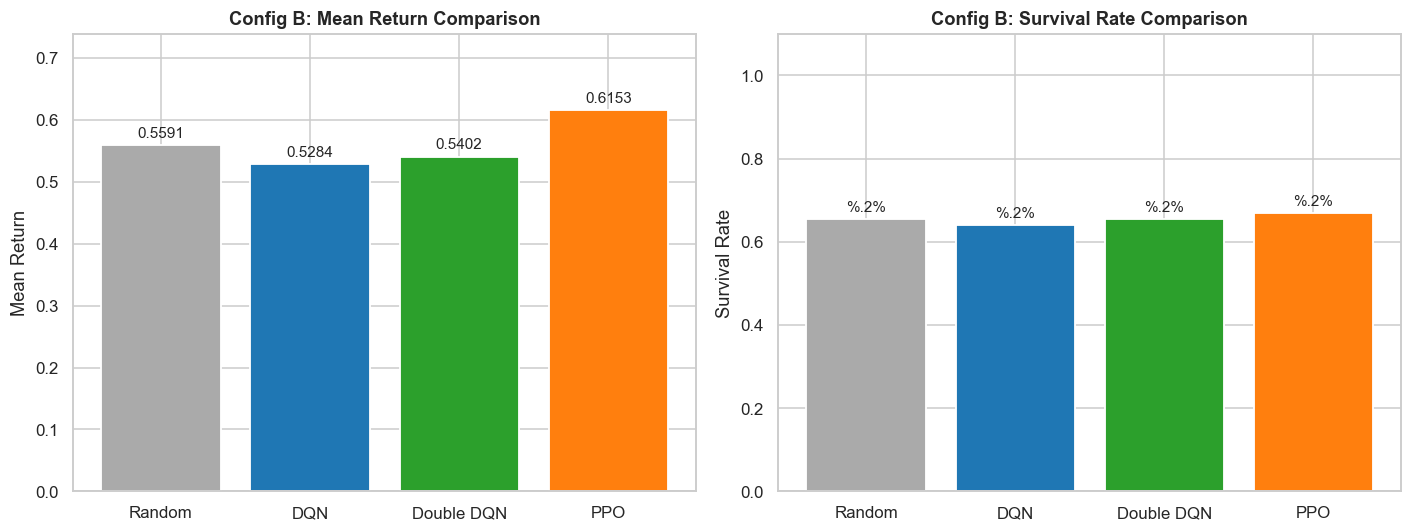

Improvement over random baseline:
  DQN           return Δ=-0.0306  survival Δ=-0.0140
  Double DQN    return Δ=-0.0189  survival Δ=-0.0010
  PPO           return Δ=+0.0562  survival Δ=+0.0140


In [ ]:
# Bar chart — mean return
algos  = comparison_df['Algorithm'].tolist()
rets   = comparison_df['Mean Return'].tolist()
colors = ['#aaaaaa', BLUE, GREEN, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(algos, rets, color=colors, edgecolor='white', linewidth=1.2)
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
axes[0].set_ylabel('Mean Return')
axes[0].set_title('Config B: Mean Return Comparison', fontweight='bold')
axes[0].set_ylim(0, max(rets) * 1.2)

survs = comparison_df['Survival Rate'].tolist()
bars2 = axes[1].bar(algos, survs, color=colors, edgecolor='white', linewidth=1.2)
axes[1].bar_label(bars2, fmt='%.2%', padding=3, fontsize=10)
axes[1].set_ylabel('Survival Rate')
axes[1].set_title('Config B: Survival Rate Comparison', fontweight='bold')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_final_comparison.png', bbox_inches='tight')
plt.show()

# Print improvement over random
rand_ret  = clinical_rand_mean
rand_surv = clinical_rand_surv
print('Improvement over random baseline:')
for name in ['DQN', 'Double DQN', 'PPO']:
    s = eval_results[name]['summary']
    print(f"  {name:13s} return Δ={s['mean_return']-rand_ret:+.4f}  "
          f"survival Δ={s['survival_rate']-rand_surv:+.4f}")

### Summary

- The **random baseline** establishes the performance floor on the full clinical
  environment with all three wrappers active.
- **DQN** and **Double DQN** are off-policy value-based methods; their key
  hyperparameters are the **replay buffer size** and the **target network update
  frequency**. A buffer that is too small leads to catastrophic forgetting;
  a target update frequency that is too high reintroduces moving-target
  instability. The Optuna search quantifies these trade-offs.
- **PPO** is an on-policy policy-gradient method with no replay buffer and no
  target network — its stability comes from the clipped objective and fresh
  rollout data, not from the DQN stabilisation mechanisms.
- The failure-mode analysis shows how each agent degrades as wrapper intensity
  increases, revealing which clinical failure mode poses the greatest challenge.